In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv(r'D:\Saran\aivivn_train.csv')

In [3]:
df

,index,discriptions,mapped_rating
0,0,dung dc sp tot cam on shop đóng gói sản phẩm ...,0
1,1,chất lượng sản phẩm tuyệt vời son mịn nhưn...,0
2,2,chất lượng sản phẩm tuyệt vời nhưng k có hộp...,0
3,3,mình hơi thất vọng chút vì mình đã kỳ vọ...,1
4,4,lần trước mình mua áo gió màu hồng rất ok mà ...,1
...,...,...,...
14872,16067,chị chủ tư vấn nhiệt tình đóng gói sản phẩm r...,0
14873,16068,chẳng biết là shop có biết đọc hay không mua ...,1
14874,16069,cuốn này mỏng đọc một buổi sáng là hết thú ...,1
14875,16071,tôi đã nhận đc hàng sau đây là vài lời muốn n...,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   index          14877 non-null  int64
 1   discriptions   14877 non-null  str  
 2   mapped_rating  14877 non-null  int64
dtypes: int64(2), str(1)
memory usage: 348.8 KB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns   

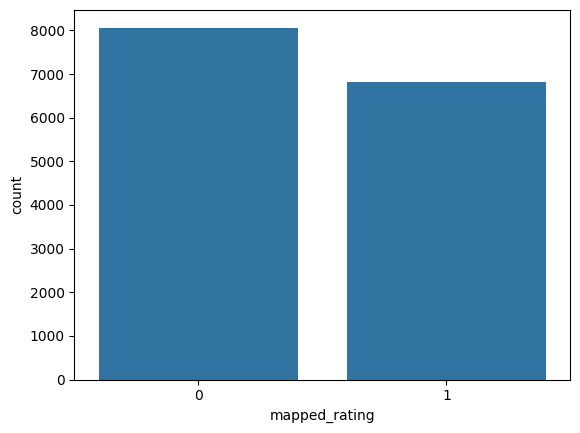

In [7]:
sns.countplot(x=df['mapped_rating'])
plt.show()

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [52]:
vectorizer = CountVectorizer()

x=vectorizer.fit_transform(df['discriptions'])
y=df['mapped_rating']

In [53]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:

from sklearn.naive_bayes import MultinomialNB

In [55]:
model=MultinomialNB()

model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [56]:
y_pred=model.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [58]:
accuarcy=accuracy_score(y_test,y_pred)

print('accuracy :' , accuarcy)

cfmx=confusion_matrix(y_test,y_pred)

print('confusion : ',cfmx)

accuracy : 0.8800403225806451
confusion :  [[1358  230]
 [ 127 1261]]


In [64]:
new = [
'dung dc sp tot cam on shop đóng gói sản phẩm rất đẹp và chắc chắn chất lượng sản phẩm tuyệt vời',
'giày đẹp lắm có điều dây hơi ngắn tí ạ  chất không hài lòng sản phẩm cho lắm  giặt lan đầu tiên da nhoe màu hết rồi'
]

new_fea = vectorizer.transform(new)  
new_pred = model.predict(new_fea)

for sentence, pred in zip(new, new_pred):
    print(f"Sentence: '{sentence}' --> Sentiment: {pred}")

Sentence: 'dung dc sp tot cam on shop đóng gói sản phẩm rất đẹp và chắc chắn chất lượng sản phẩm tuyệt vời' --> Sentiment: 0
Sentence: 'giày đẹp lắm có điều dây hơi ngắn tí ạ  chất không hài lòng sản phẩm cho lắm  giặt lan đầu tiên da nhoe màu hết rồi' --> Sentiment: 1
